<a href="https://colab.research.google.com/github/hjfuentes/UCH_FCFM/blob/main/DMAvanzado/M01_MatEst/Laboratorio_5_Estad_stica_Comparativa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

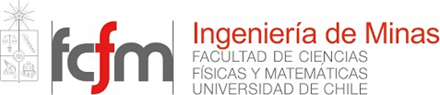

# **Laboratorio 5: Estadística Comparativa Aplicada**
*Curso: Matemática y estadística fundamental para el modelamiento en minería y metalurgia*

*Diploma de Apliciones de Modelamiento Avanzado en Minería y Metalurgia*

*Profesores: Xavier Emery, Nadia Mery y Fabián Soto*



# **Highlights de este laboratorio**

En este laboratorio aprenderás a:

- Comprender el concepto de muestreo estadístico.
- Formular hipótesis estadísticas.
- Aplicar pruebas estadísticas comparativas.
- Comparar muestras y grupos mediante evidencia estadística.
- Uso de pruebas t y pruebas no paramétricas.
- Aplicación de ANOVA en problemas minero-metalúrgicos.
- Interpretación de p-values y significancia estadística.
- Comparar desempeño entre procesos, campañas o turnos.
- Evaluar diferencias operacionales mediante análisis estadístico.
- Construir conclusiones basadas en evidencia cuantitativa.

# **Estadística comparativa**

Muchas veces no basta con describir datos.

También necesitamos responder preguntas como:

- ¿dos procesos son distintos?;
- ¿una mejora operacional tuvo efecto?;
- ¿las diferencias observadas podrían explicarse por azar?

La estadística comparativa permite responder este tipo de preguntas utilizando datos.

**Librerías a utilizar**

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

En este laboratorio usaremos nuevamente Google Drive, necesitarás editar estos bloques de código según la ubicación en que tengas guardados tus archivos:

In [ ]:
from google.colab import drive # Importar librería de Google Drive
drive.mount('/content/drive') # Montar Google Drive para poder usarlo en este Colab

Mounted at /content/drive


In [ ]:
# Indicar qué la ruta del archivo a cargar
#   Modificar la ruta en caso de ser necesario,dependiendo
#   de dónde guardaron el archivo yacimiento_ferrifero
dh_df = pd.read_csv("/content/drive/MyDrive/DIMIN/DIMIN2026/DiploModelamientoDatos/Módulo1/Jupyter/dh_df_limpio.csv", delimiter = ",")

No olvidar lo que significa cada variable

|Nombre|Variable|
|------|--------|
|Easting|Coordenada este|
|Northing|Coordenada norte|
|Elevation|Coordenada elevación|
|Fe|Contenido de Fierro (%)|
|Si|Contenido de Sílice (%)|
|P|Contenido de Fosforo (%)|
|Mn|Contenido de Manganeso (%)|
|Pf|Pérdida de fuego - % en masa perdido por elemento sometido a una T° específica|
|G1|Fracción granulométrica con tamaño particula >6.3 mm (%)|
|Rocktype|Tipo de roca|

# **1 - Intervalo de confianza para la media**

Una muestra entrega una estimación de la realidad, pero siempre existe incertidumbre.

Los intervalos de confianza permiten estimar un rango probable para un parámetro poblacional.

**1.1. Ejemplo introductorio**

In [ ]:
# Recuperaciones (%)
recuperacion = np.array([82, 84, 85, 83, 86])

In [ ]:
# Nivel de confianza
confidence = 0.95

# Media muestral
media = np.mean(recuperacion)

# Tamaño de la muestra
n = len(recuperacion)

print(f"Media muestral: {media}")
print(f"Tamaño de muestra: {n}")

Media muestral: 84.0
Tamaño de muestra: 5


**1.1.1 Intervalo de confianza para varianza conocida**

Si conocemos la desviación estándar poblacional, podemos usar la distribución normal.

In [ ]:
sigma = 2
# Desviación estándar poblacional conocida
# Este valor debe ser conocido previamente.
# Si no se conoce, debe utilizarse la distribución t de Student.

error_estandar = sigma / np.sqrt(n)
# Calcular error estándar usando la desviación estándar poblacional

# Calcular intervalo de confianza usando distribución normal
ic_normal = stats.norm.interval(
    confidence=confidence,  # Nivel de confianza (por ejemplo 95%)
    loc=media,              # Media muestral
    scale=error_estandar    # Error estándar
)

li_normal = ic_normal[0] # Extraer límite inferior del intervalo
ls_normal = ic_normal[1] # Extraer límite superior del intervalo

# Mostrar resultados
print("="*50)
print("IC con varianza conocida (Distribución Normal)")
print("="*50)
print(f"Media muestral : {media:.2f}") # Mostrar media de la muestra
print(f"Límite inferior: {li_normal:.2f}") # Mostrar límite inferior del intervalo
print(f"Límite superior: {ls_normal:.2f}") # Mostrar límite superior del intervalo
print(f"IC 95%         : [{li_normal:.2f}, {ls_normal:.2f}]") # Mostrar intervalo de confianza completo

IC con varianza conocida (Distribución Normal)
Media muestral : 84.00
Límite inferior: 82.25
Límite superior: 85.75
IC 95%         : [82.25, 85.75]


**1.1.2. Intervalo de confianza para varianza desconocida**

En problemas reales normalmente no conocemos la desviación estándar poblacional.

Por eso usamos la desviación estándar muestral y la distribución t-Student.

In [ ]:
# Calcular intervalo de confianza usando distribución t de Student
ic_t = stats.t.interval(
    confidence=confidence,   # Nivel de confianza (por ejemplo 95%)
    df=n-1,                  # Grados de libertad
    loc=media,               # Media muestral
    scale=stats.sem(recuperacion)  # Error estándar de la media
)

li_t = ic_t[0] # Extraer límite inferior del intervalo
ls_t = ic_t[1] # Extraer límite superior del intervalo

# Mostrar resultados
print("="*55)
print("IC con varianza desconocida (t-Student)")
print("="*55)
print(f"Media muestral : {media:.2f}")
print(f"Límite inferior: {li_t:.2f}")
print(f"Límite superior: {ls_t:.2f}")
print(f"IC 95%         : [{li_t:.2f}, {ls_t:.2f}]")

IC con varianza desconocida (t-Student)
Media muestral : 84.00
Límite inferior: 82.04
Límite superior: 85.96
IC 95%         : [82.04, 85.96]


**Comparación de resultados**

Observamos que el intervalo usando t-Student es ligeramente más amplio.

Esto ocurre porque:

- no conocemos la varianza poblacional;
- y existe mayor incertidumbre al estimarla desde una muestra pequeña.

En problemas reales, normalmente utilizamos la distribución t-Student.

In [ ]:
# Crear tabla comparativa de intervalos de confianza

comparacion_ic = pd.DataFrame({
    "Método": ["Normal (varianza conocida)", "t-Student (varianza desconocida)"],
    "Límite inferior (%)": [li_normal, li_t],
    "Límite superior (%)": [ls_normal, ls_t]
}).round(2)

# Mostrar tabla
comparacion_ic

,Método,Límite inferior (%),Límite superior (%)
0,Normal (varianza conocida),82.25,85.75
1,t-Student (varianza desconocida),82.04,85.96


**1.2. Aplicación a datos reales**

Ahora aplicaremos intervalos de confianza a un dataset real de sondajes mineros.

El objetivo será estimar un rango plausible para el contenido promedio de Fe según el tipo de roca.

In [ ]:
# Separar el DataFrame en tres subconjuntos, uno por cada tipo de roca
# Esto permite analizar y comparar cada grupo de forma independiente
dh_rock_type1 = dh_df.loc[dh_df["Rocktype"] == 1]
dh_rock_type2 = dh_df.loc[dh_df["Rocktype"] == 2]
dh_rock_type3 = dh_df.loc[dh_df["Rocktype"] == 3]

**1.2.1. Intervalo de confianza para varianza desconocida**

En este caso corresponder aplicar el intervalo de confianza para la media con varianza desconocida, debido a que no conocemos la varianza poblacional. Lo haremos creando una función



In [ ]:
# Función para calcular un intervalo de confianza usando t de Student
def calcular_ic_t(datos, variable, confianza=0.95):

    n = len(datos)   # Obtener tamaño de muestra
    media = datos[variable].mean()    # Calcular media muestral de la variable
    error_estandar = stats.sem(datos[variable])    # Calcular error estándar de la media

    ic = stats.t.interval(
        confidence=confianza,  # Nivel de confianza
        df=n-1,                # Grados de libertad
        loc=media,             # Media muestral
        scale=error_estandar   # Error estándar
    )

    # Retornar media, límite inferior y límite superior
    return media, ic[0], ic[1]

In [ ]:
# Calcular intervalos para cada tipo de roca

media_1, li_1, ls_1 = calcular_ic_t(dh_rock_type1, "Fe")
media_2, li_2, ls_2 = calcular_ic_t(dh_rock_type2, "Fe")
media_3, li_3, ls_3 = calcular_ic_t(dh_rock_type3, "Fe")

In [ ]:
# Crear tabla comparativa

ic_rocas = pd.DataFrame({
    "Rocktype": [1, 2, 3],
    "Media Fe (%)": [media_1, media_2, media_3],
    "Límite inferior (%)": [li_1, li_2, li_3],
    "Límite superior (%)": [ls_1, ls_2, ls_3]
}).round(2)

ic_rocas

,Rocktype,Media Fe (%),Límite inferior (%),Límite superior (%)
0,1,64.77,64.47,65.07
1,2,66.12,65.65,66.59
2,3,63.80,63.54,64.05


**Interpretación**

Cada intervalo representa un rango plausible para el contenido promedio de Fe en cada tipo de roca.

Si los intervalos están muy separados, puede ser una primera señal de diferencias entre tipos de roca. Sin embargo, para evaluar formalmente esas diferencias usaremos pruebas estadísticas.

**1.2.2. Reutilizando la función creada para IC**

Una ventaja de crear funciones es que podemos reutilizarlas fácilmente:

- cambiando la variable
- cambiando el nivel de confianza
- o aplicándola a otros subconjuntos de datos.

In [ ]:
# Calcular IC para la variable Si
# usando roca tipo 1

media, li, ls = calcular_ic_t(
    dh_rock_type1,
    "Si"
)

print(f"IC 95% Si: [{li:.2f}, {ls:.2f}]")

IC 95% Si: [3.58, 4.36]


In [ ]:
# Calcular IC al 99% para Fe en tipo roca 1

media, li, ls = calcular_ic_t(
    dh_rock_type1,
    "Fe",
    confianza=0.99
)

print(f"IC 99% Fe: [{li:.2f}, {ls:.2f}]")

IC 99% Fe: [64.38, 65.17]


**Observación**

Al aumentar el nivel de confianza:

- el intervalo se vuelve más amplio;
- porque necesitamos mayor certeza para cubrir el parámetro poblacional.

> ## 🛠️ Mini desafío 1
>
> Utilizar la función `calcular_ic_t()` para:
>
> - calcular un IC al 90% para Fe en la roca 2
> - calcular un IC al 95% de variable Mn en la roca 1

>

# **2 - Distribuciones y normalidad**

Muchos métodos estadísticos asumen que los datos siguen una distribución aproximadamente normal.

Por eso, antes de aplicar pruebas estadísticas, suele ser útil explorar cómo se distribuyen los datos.

Lo más sencillo es la inspección visual utilizando el histograma

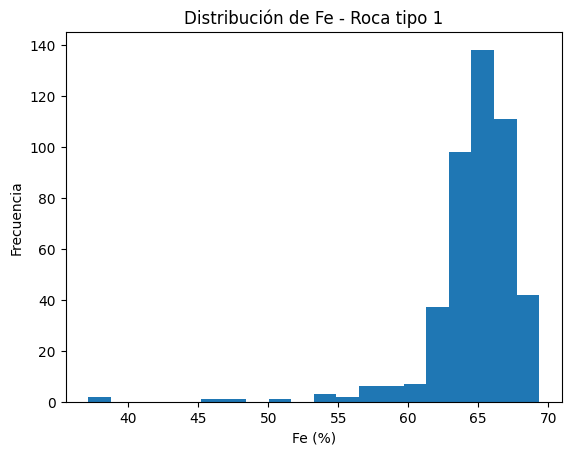

In [ ]:
# Histograma del contenido de Fe en el tipo de roca 1
plt.hist(dh_rock_type1["Fe"],bins=20)

# Agregar título y etiquetas
plt.title("Distribución de Fe - Roca tipo 1")
plt.xlabel("Fe (%)")
plt.ylabel("Frecuencia")
plt.show()

**Interpretación**

Sigue una distribución Gaussiana (normal) la ley de Fe en el tipo de roca 1?

**2.1. Test de Shapiro-Wilk**

El test de Shapiro-Wilk permite evaluar si un conjunto de datos sigue una distribución normal.

- Hipótesis nula ($H_0$): los datos siguen una distribución normal.
- Hipótesis alternativa ($H_1$): los datos no siguen una distribución normal.

Interpretación básica:

- Si `p-value > 0.05`, no se rechaza la normalidad.
- Si `p-value <= 0.05`, se rechaza la normalidad.

In [ ]:
# Aplicar test de normalidad Shapiro-Wilk para las leyes de Fe en el tipo de roca 1
shapiro_test = stats.shapiro(dh_rock_type1["Fe"])

# Extraer estadístico y p-value
statistic = shapiro_test.statistic
p_value = shapiro_test.pvalue

# Mostrar resultados
print("="*40)
print("Test de Shapiro-Wilk")
print("="*40)
print(f"Estadístico : {statistic:.4f}")
print(f"p-value     : {p_value:.4f}")

# Interpretación del resultado

if p_value <= 0.05:
    print("Como p-value es menor o igual a 0.05, se rechaza la hipótesis de normalidad.")
else:
    print("Como p-value es mayor a 0.05, no existe evidencia suficiente para rechazar la normalidad.")

Test de Shapiro-Wilk
Estadístico : 0.7099
p-value     : 0.0000
Como p-value es menor o igual a 0.05, se rechaza la hipótesis de normalidad.


**2.2 Test de chi cuadrado**

El test Chi-cuadrado permite evaluar si un conjunto de datos sigue una distribución teórica esperada, como la distribución normal.

- Hipótesis nula ($H_0$): los datos siguen una distribución normal.
- Hipótesis alternativa ($H_1$): los datos no siguen una distribución normal.

Interpretación básica:

- Si `p-value > 0.05`, no se rechaza la normalidad.
- Si `p-value <= 0.05`, se rechaza la normalidad.

In [ ]:
# Calcular histograma observado
observado, bins = np.histogram(dh_rock_type1["Fe"],bins=10)

# Calcular media y desviación estándar muestral
media = np.mean(dh_rock_type1["Fe"])
desv = np.std(dh_rock_type1["Fe"], ddof=1)

# Calcular probabilidades esperadas por intervalo
probabilidades = np.diff(stats.norm.cdf(bins,loc=media,scale=desv))

# Calcular frecuencias esperadas
esperado = len(dh_rock_type1["Fe"]) * probabilidades

# Ajustar las frecuencias esperadas para que sumen igual que las observadas
esperado = esperado * observado.sum() / esperado.sum()

# Aplicar test chi-cuadrado
chi2, p_value = stats.chisquare(
    f_obs=observado,
    f_exp=esperado
)

# Mostrar resultados
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-value     : {p_value:.4f}")

# Interpretación del resultado

if p_value <= 0.05:
    print("Como p-value es menor o igual a 0.05, se rechaza la hipótesis de normalidad.")
else:
    print("Como p-value es mayor a 0.05, no existe evidencia suficiente para rechazar la normalidad.")

Chi-cuadrado: 203576377282.0457
p-value     : 0.0000
Como p-value es menor o igual a 0.05, se rechaza la hipótesis de normalidad.


Tanto el hitograma, el test de Shapiro-Wilks y chi cuadrado indican que las leyes de Fe en el tipo de roca 1 no siguen una distribución Gaussiana.

> ## 🛠️ Mini desafío 2
>
> Evaluar normalidad para Si en el tipo de roca 2
>
> Utilizar:
>
> - histogramas
> - test de Shapiro-Wilk
> - test de chi cuadrado
>
> Luego interpretar los resultados.

# **3 - Test de hipótesis**

Los test de hipótesis permiten evaluar si una diferencia observada podría explicarse por azar o representa una diferencia estadísticamente significativa.

En minería y metalurgia, este tipo de análisis puede utilizarse para comparar:

- tipos de roca
- procesos operacionales
- recuperaciones
- leyes
- o campañas distintas.

**Hipótesis estadísticas**

Los test estadísticos comparan dos hipótesis:

- Hipótesis nula ($H_0$):
  no existen diferencias.

- Hipótesis alternativa ($H_1$):
  sí existen diferencias.


### **3.1 Test de Fisher: Comparación de varianzas**

El test F de Fisher permite comparar si dos grupos poseen varianzas similares.

**Hipótesis**

- Hipótesis nula ($H_0$):
  ambas varianzas son iguales.

- Hipótesis alternativa ($H_1$):
  las varianzas son diferentes.

**Supuestos del test F de Fisher**

El test F de Fisher asume:

- independencia entre observaciones
- distribución aproximadamente normal
- y muestras representativas.

La normalidad puede evaluarse previamente utilizando histogramas o test como Shapiro-Wilk.

**Veamos un ejemplo introductorio**

Se desea comparar si hay diferencias en la variabilidad entre el Grupo A y el Grupo B. Para esto se realiza un **test de Fisher bilateral**

**Hipótesis**

- Hipótesis nula ($H_0$):
  $\sigma^2_{GA}=\sigma^2_{GB}$.

- Hipótesis alternativa ($H_1$):
  $\sigma^2_{GA}\neq\sigma^2_{GB}$.

In [ ]:
# Grupo A
grupo_A = [80, 82, 81, 79, 83]

# Grupo B
grupo_B = [90, 95, 85, 100, 88]

In [ ]:
# Calcular varianzas
var_A = np.var(grupo_A, ddof=1)
var_B = np.var(grupo_B, ddof=1)

print(f"Varianza grupo A: {var_A:.2f}")
print(f"Varianza grupo B: {var_B:.2f}")

Varianza grupo A: 2.50
Varianza grupo B: 35.30


In [ ]:
# Calcular estadístico F
F = var_A / var_B

# Grados de libertad
df1 = len(grupo_A) - 1
df2 = len(grupo_B) - 1

# Calcular p-value bilateral
p_value = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

# Mostrar resultados
print(f"F statistic: {F:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: las varianzas son diferentes.")
else:
    print("No existe evidencia suficiente para rechazar H0: las varianzas son iguales.")

F statistic: 0.0708
p-value    : 0.0251
Se rechaza H0: las varianzas son diferentes.


**Hipótesis unilateral y bilateral**

En este ejemplo utilizamos una hipótesis alternativa bilateral $H_1$: las varianzas son diferentes.

Si el interés fuera evaluar si una varianza es específicamente mayor o menor que otra, se utilizaría una hipótesis unilateral.

**Hipótesis unilateral: varianza mayor de Grupo B**

- Hipótesis nula ($H_0$):
  $\sigma^2_{GA}\geq\sigma^2_{GB}$.

- Hipótesis alternativa ($H_1$):
  $\sigma^2_{GA}<\sigma^2_{GB}$.

In [ ]:
# H1: varianza de A menor que varianza de B

p_menor = stats.f.cdf(F,df1,df2)

print(f"p-value (H1: A < B): {p_menor:.4f}")

# Interpretación

if p_menor <= 0.05:
    print("Se rechaza H0: las varianzas GA son menores a varianzas GB.")
else:
    print("No existe evidencia suficiente para rechazar H0: las varianzas de GA son mayores o iguales a las de GB.")

p-value (H1: A < B): 0.0125
Se rechaza H0: las varianzas GA son menores a varianzas GB.


**Hipótesis unilateral: varianza mayor de Grupo A**

- Hipótesis nula ($H_0$):
  $\sigma^2_{GA}\leq\sigma^2_{GB}$.

- Hipótesis alternativa ($H_1$):
  $\sigma^2_{GA}>\sigma^2_{GB}$.

In [ ]:
# H1: varianza de A mayor que varianza de B

p_mayor = 1 - stats.f.cdf(F,df1,df2)

print(f"p-value (H1: A > B): {p_mayor:.4f}")


# Interpretación

if p_mayor <= 0.05:
    print("Se rechaza H0: las varianzas GA son mayores varianzas GB.")
else:
    print("No existe evidencia suficiente para rechazar H0: las varianzas de GA son menores o iguales a las de GB.")

p-value (H1: A > B): 0.9875
No existe evidencia suficiente para rechazar H0: las varianzas de GA son menores o iguales a las de GB.


###**3.2 Test de Student: Comparación de medias**

El test t de Student permite evaluar si dos grupos tienen medias significativamente diferentes.

En este ejemplo queremos comparar si el promedio del Grupo A es distinto al promedio del Grupo B.

**Hipótesis bilateral**

- Hipótesis nula ($H_0$): $\mu_{GA} = \mu_{GB}$
- Hipótesis alternativa ($H_1$): $\mu_{GA} \neq \mu_{GB}$

**Supuestos del test t de Student**

El test t de Student asume:

- independencia entre observaciones
- distribución aproximadamente normal


In [ ]:
# Calcular medias de ambos grupos

media_A = np.mean(grupo_A)
media_B = np.mean(grupo_B)

print(f"Media grupo A: {media_A:.2f}")
print(f"Media grupo B: {media_B:.2f}")

Media grupo A: 81.00
Media grupo B: 91.60


In [ ]:
# Aplicar test t de Student para muestras independientes
# equal_var=False depende del resultado del test de Fisher
# alternative='two-sided' define que es bilateral

t_stat, p_value = stats.ttest_ind(grupo_A,grupo_B,equal_var=False,alternative='two-sided')

# Mostrar resultados
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: las medias son diferentes.")
else:
    print("No existe evidencia suficiente para rechazar H0: las medias son iguales.")

t-statistic: -3.8552
p-value    : 0.0142
Se rechaza H0: las medias son diferentes.


**Hipótesis unilateral: media de Grupo A menor que Grupo B**

- Hipótesis nula ($H_0$): $\mu_{GA} \geq \mu_{GB}$
- Hipótesis alternativa ($H_1$): $\mu_{GA} < \mu_{GB}$

In [ ]:
# Aplicar test unilateral
# H1: media de A menor que media de B
# alternative='less' define que es unilateral con A menor que B como hipótesis alternativa

t_stat, p_value = stats.ttest_ind(grupo_A,grupo_B,equal_var=False,alternative='less')

# Mostrar resultados
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: la media de A es menor que la media de B.")
else:
    print("No existe evidencia suficiente para concluir que la media de A es menor que la media de B.")

t-statistic: -3.8552
p-value    : 0.0071
Se rechaza H0: la media de A es menor que la media de B.


**Hipótesis unilateral: media de Grupo A mayor que Grupo B**

- Hipótesis nula ($H_0$): $\mu_{GA} \leq \mu_{GB}$
- Hipótesis alternativa ($H_1$): $\mu_{GA} > \mu_{GB}$

In [ ]:
# Aplicar test unilateral
# H1: media de A mayor que media de B
# alternative='greater' define que es unilateral con A mayor que B como hipótesis alternativa

t_stat, p_value = stats.ttest_ind(grupo_A,grupo_B,equal_var=False,alternative='greater')

# Mostrar resultados
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: la media de A es mayor que la media de B.")
else:
    print("No existe evidencia suficiente para concluir que la media de A es mayor que la media de B.")

t-statistic: -3.8552
p-value    : 0.9929
No existe evidencia suficiente para concluir que la media de A es mayor que la media de B.


###**3.3 Aplicación a datos reales**

Ahora aplicaremos test estadísticos al dataset de sondajes mineros.

El objetivo será evaluar si existen diferencias estadísticas entre:

- roca tipo 1 y roca tipo 2.

**3.3.1 Fisher: comparación de varianzas**

Hipótesis

- Hipótesis nula ($H_0$):
  $\sigma^2_{RT1} = \sigma^2_{RT2}$

- Hipótesis alternativa ($H_1$):
  $\sigma^2_{RT1} \neq \sigma^2_{RT2}$

In [ ]:
# Filtrar contenido de Fe para roca tipo 1
fe_rock1 = dh_df.loc[dh_df["Rocktype"] == 1,"Fe"]

# Filtrar contenido de Fe para roca tipo 2
fe_rock2 = dh_df.loc[dh_df["Rocktype"] == 2,"Fe"]

In [ ]:
# Calcular varianzas muestrales
var_1 = np.var(fe_rock1,ddof=1)
var_2 = np.var(fe_rock2,ddof=1)

# Mostrar resultados
print(f"Varianza roca tipo 1: {var_1:.2f}")
print(f"Varianza roca tipo 2: {var_2:.2f}")

Varianza roca tipo 1: 10.69
Varianza roca tipo 2: 17.45


In [ ]:
# Calcular estadístico F
F = var_1 / var_2

# Grados de libertad
df1 = len(fe_rock1) - 1
df2 = len(fe_rock2) - 1

# Calcular p-value bilateral
p_value = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))

# Mostrar resultados
print(f"F statistic: {F:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: las varianzas son diferentes.")
else:
    print("No existe evidencia suficiente para rechazar H0: las varianzas son iguales.")

F statistic: 0.6123
p-value    : 0.0000
Se rechaza H0: las varianzas son diferentes.


**3.3.2 Student: comparación de medias**

Hipótesis

- Hipótesis nula ($H_0$):
  $\mu_{RT1} = \mu_{RT2}$

- Hipótesis alternativa ($H_1$):
  $\mu_{RT1} \neq \mu_{RT2}$

In [ ]:
# Calcular medias
media_1 = np.mean(fe_rock1)
media_2 = np.mean(fe_rock2)

# Mostrar resultados
print(f"Media Fe roca tipo 1: {media_1:.2f}")
print(f"Media Fe roca tipo 2: {media_2:.2f}")

Media Fe roca tipo 1: 64.77
Media Fe roca tipo 2: 66.12


In [ ]:
# Aplicar test t de Student para muestras independientes
# equal_var=False del resultados del test de Fisher
# Test bilateral alternative='two-sided'

t_stat, p_value = stats.ttest_ind(fe_rock1,fe_rock2,equal_var=False,alternative='two-sided')

# Mostrar resultados
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: existen diferencias significativas entre las medias.")
else:
    print("No existe evidencia suficiente para rechazar H0: las medias son iguales.")

t-statistic: -4.7616
p-value    : 0.0000
Se rechaza H0: existen diferencias significativas entre las medias.


**Comparación visual entre ambos grupos**

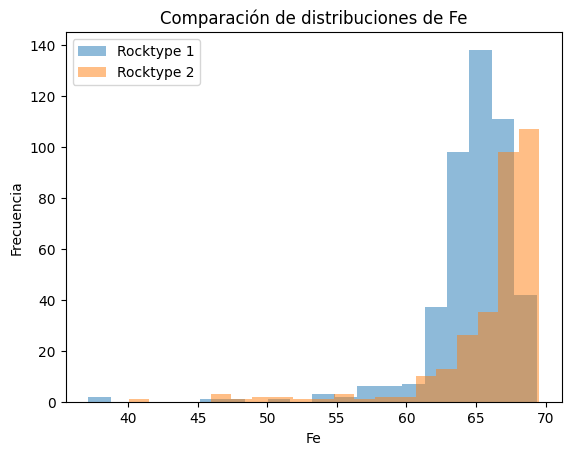

In [ ]:
# Visualizar distribuciones de Fe

plt.hist(fe_rock1,bins=20,alpha=0.5,label="Rocktype 1")

plt.hist(fe_rock2,bins=20,alpha=0.5,label="Rocktype 2")

plt.xlabel("Fe")
plt.ylabel("Frecuencia")
plt.title("Comparación de distribuciones de Fe")
plt.legend()
plt.show()

> ## 🛠️ Mini desafío 3
>
> Repetir el análisis utilizando:
>
> - la variable `Si`;
> - roca tipo 2;
> - y roca tipo 3.
>
> El análisis debe incluir:
>
> - test de Fisher
> - test t de Student
> - e interpretación de resultados.

# **4 - ANOVA: Comparación de múltiples grupos**

El test ANOVA (Analysis of Variance) permite comparar las medias de más de dos grupos simultáneamente.

En este caso queremos evaluar si el contenido promedio de Fe difiere entre:

- roca tipo 1;
- roca tipo 2;
- roca tipo 3.

**Hipótesis**

- Hipótesis nula ($H_0$):
  $\mu_{RT1} = \mu_{RT2} = \mu_{RT3}$ o no hay efecto del tipo de roca en la concentración de Fe

- Hipótesis alternativa ($H_1$):
  al menos una media es diferente o si hay efecto del tipo de roca en la concentración de Fe

**Supuestos de ANOVA**

ANOVA asume:

- independencia entre observaciones
- distribución aproximadamente normal dentro de cada grupo
- y homogeneidad de varianzas entre grupos.

En las secciones anteriores utilizamos:

- Shapiro-Wilk para evaluar normalidad
- y Fisher para comparar varianzas.

**Observación**

En aplicaciones reales, los supuestos rara vez se cumplen perfectamente.

Sin embargo, muchos métodos estadísticos son relativamente robustos a pequeñas desviaciones de estos supuestos.

In [ ]:
# Filtrar contenido de Fe por tipo de roca

fe_rock1 = dh_df.loc[dh_df["Rocktype"] == 1,"Fe"]
fe_rock2 = dh_df.loc[dh_df["Rocktype"] == 2,"Fe"]
fe_rock3 = dh_df.loc[dh_df["Rocktype"] == 3,"Fe"]

# Mostrar medias por grupo

print(f"Media Fe roca tipo 1: {fe_rock1.mean():.2f}")
print(f"Media Fe roca tipo 2: {fe_rock2.mean():.2f}")
print(f"Media Fe roca tipo 3: {fe_rock3.mean():.2f}")

Media Fe roca tipo 1: 64.77
Media Fe roca tipo 2: 66.12
Media Fe roca tipo 3: 63.80


In [ ]:
# Aplicar ANOVA

f_stat, p_value = stats.f_oneway(fe_rock1,fe_rock2,fe_rock3)

# Mostrar resultados
print(f"F statistic: {f_stat:.4f}")
print(f"p-value    : {p_value:.4f}")

# Interpretación
if p_value <= 0.05:
    print("Se rechaza H0: al menos una media es diferente.")
else:
    print("No existe evidencia suficiente para rechazar H0: las medias son iguales.")

F statistic: 33.7277
p-value    : 0.0000
Se rechaza H0: al menos una media es diferente.


**Interpretación**

ANOVA permite evaluar si existen diferencias globales entre múltiples grupos.

Sin embargo, el test no indica específicamente qué grupos son distintos entre sí.

Para eso se requieren análisis post-hoc adicionales.

Es un test que siempre es unilateral.

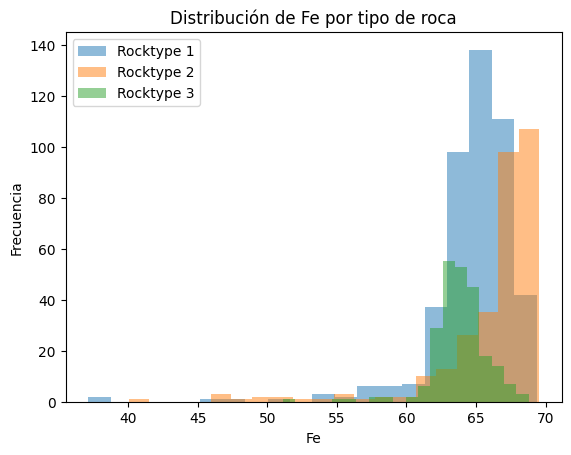

In [ ]:
# Visualizar distribuciones de Fe

plt.hist(fe_rock1,bins=20,alpha=0.5,label="Rocktype 1")
plt.hist(fe_rock2,bins=20,alpha=0.5,label="Rocktype 2")
plt.hist(fe_rock3,bins=20,alpha=0.5,label="Rocktype 3")

plt.xlabel("Fe")
plt.ylabel("Frecuencia")
plt.title("Distribución de Fe por tipo de roca")
plt.legend()
plt.show()

/tmp/ipykernel_10282/816255792.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fe_rock1, fe_rock2, fe_rock3],labels=["RT1", "RT2", "RT3"])


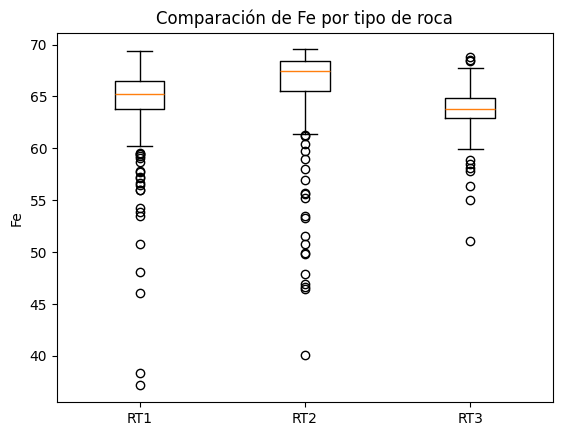

In [ ]:
# Crear boxplot comparativo

plt.boxplot([fe_rock1, fe_rock2, fe_rock3],labels=["RT1", "RT2", "RT3"])


plt.ylabel("Fe")
plt.title("Comparación de Fe por tipo de roca")
plt.show()

> ## 🛠️ Mini desafío 4
>
> Repetir el análisis ANOVA utilizando:
>
> - la variable `Mn`.
>
> El análisis debe incluir:
>
> - cálculo de medias
> - ANOVA
> - interpretación del p-value
> - y visualización mediante histogramas o boxplots.

# Resumen conceptual

| Método | Objetivo |
|---|---|
| Intervalo de confianza | estimar rango plausible |
| Shapiro | evaluar normalidad |
| Fisher | comparar varianzas |
| Student | comparar medias |
| ANOVA | comparar medias de múltiples grupos |

# <font color='green'>**Extra: ¿Qué hacer si no se cumplen los supuestos?**</font>

En aplicaciones reales, los datos no siempre cumplen perfectamente:

- normalidad
- independencia
- o igualdad de varianzas.

En estos casos existen métodos alternativos, llamados métodos no paramétricos, que requieren menos supuestos.

**Alternativas comunes**

| Objetivo | Test paramétrico | Alternativa más robusta / no paramétrica |
|---|---|---|
| Evaluar normalidad | Shapiro-Wilk | Anderson-Darling |
| Comparar varianzas | Fisher | Levene |
| Comparar dos medias | t de Student | Mann-Whitney |
| Comparar múltiples grupos | ANOVA | Kruskal-Wallis |

In [ ]:
# Ejemplo Test de Mann-Whitney

statistic, p_value = stats.mannwhitneyu(fe_rock1,fe_rock2)

# Mostrar resultados

print(f"Statistic : {statistic:.4f}")
print(f"p-value   : {p_value:.4f}")

# Interpretación

if p_value <= 0.05:
    print("Se rechaza H0: existen diferencias entre ambos grupos.")
else:
    print("No existe evidencia suficiente para rechazar H0.")

Statistic : 38514.0000
p-value   : 0.0000
Se rechaza H0: existen diferencias entre ambos grupos.
